In [1]:
import sys
from pathlib import Path

# Add project root to Python path
root = Path().resolve().parents[0]  # go up from notebooks/
sys.path.append(str(root))

In [ ]:
!pip uninstall -y fitz
!pip install --upgrade pymupdf

In [7]:
# generate test ipd
import numpy as np
import pandas as pd

np.random.seed(733)

n = 300

# simulate survival times (exponential)
true_time = np.random.exponential(scale=10, size=n)

# simulate censoring times
censor_time = np.random.exponential(scale=15, size=n)

# observed data
time = np.minimum(true_time, censor_time)
event = (true_time <= censor_time).astype(int)

df = pd.DataFrame({
    "time": time,
    "event": event
})

df.head()

,time,event
0,14.376960,0
1,0.340566,1
2,12.318834,1
3,2.203676,1
4,1.873423,0


In [9]:
from src.simulation.km_renderer import build_km_render_from_ipd
from src.cen_km.reconstruct import reconstruct_ipd_basic, reconstruct_ipd_with_censoring

render = build_km_render_from_ipd(df, time_col="time", event_col="event")

basic = reconstruct_ipd_basic(render.curve_points, n_initial=len(df))
censor_aware = reconstruct_ipd_with_censoring(
    render.curve_points,
    render.censor_points,
    n_initial=len(df),
)

basic.event_table.head()
censor_aware.event_table.head()

,time,survival_target,survival_reconstructed,n_risk,n_events,n_censored,interval_error
0,0.000000,1.000000,1.000000,300,0,0,NaN
1,0.001462,0.996667,0.996667,300,1,0,5.551115e-16
2,0.009664,0.993333,0.993333,299,1,0,2.220446e-16
3,0.017898,0.993333,0.993333,298,0,1,2.220446e-16
4,0.042070,0.993333,0.993333,297,0,1,2.220446e-16


In [10]:
from src.validation.metrics import summary_metrics

metrics = summary_metrics(df, censor_aware.ipd, t0=10)
metrics

{'km_rmse': 0.0, 'survival_diff_t0': 0.0, 'n_true': 300, 'n_recon': 300}

In [11]:
from src.cen_km.risk_table_alignment import compute_n_at_risk, align_ipd_to_risk_table, risk_table_error

# toy published risk table sampled from the true IPD
risk_times = [0, 5, 10, 15, 20]
risk_table = compute_n_at_risk(df, risk_times)

# perturb reconstructed IPD first if you want to see alignment do something
ipd_aligned = align_ipd_to_risk_table(censor_aware.ipd, risk_table)

risk_table_error(ipd_aligned, risk_table)

,time,n_risk_reconstructed,n_risk_target,error
0,0.0,300,300,0
1,5.0,146,146,0
2,10.0,73,73,0
3,15.0,24,24,0
4,20.0,5,5,0


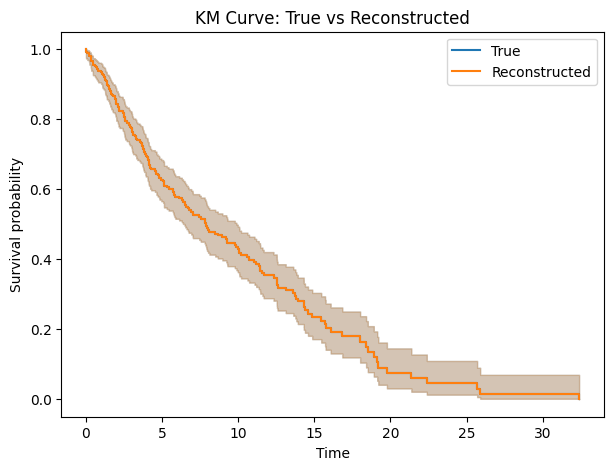

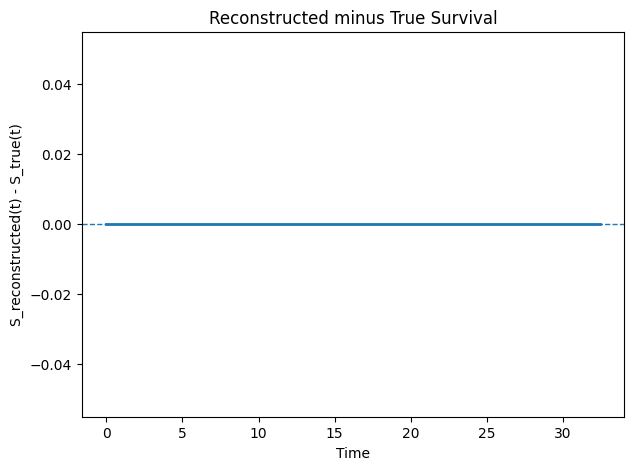

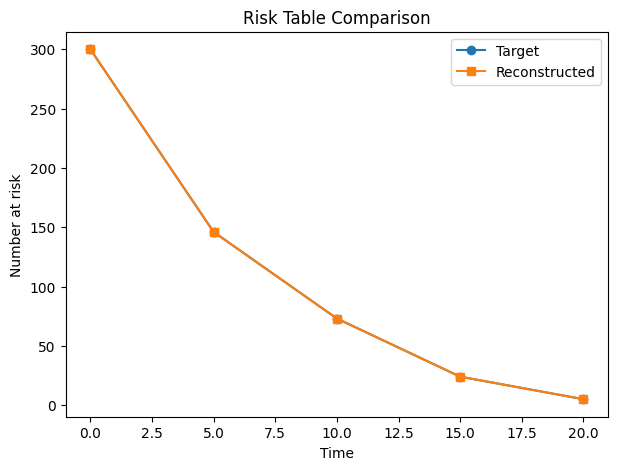

In [12]:
from src.validation.plots import (
    plot_km_comparison,
    plot_survival_difference_curve,
    plot_risk_table_comparison,
)
from src.cen_km.risk_table_alignment import risk_table_error

fig, ax = plot_km_comparison(df, censor_aware.ipd)
plt.show()

fig, ax = plot_survival_difference_curve(df, censor_aware.ipd)
plt.show()

risk_comp = risk_table_error(ipd_aligned, risk_table)
fig, ax = plot_risk_table_comparison(risk_comp)
plt.show()